In [ ]:
#STEP 1:Loaded Dataset
import pandas as pd
df = pd.read_csv(r"C:\Users\GAYATHRI\Downloads\Cricket_EDA_Project\cricketdata.csv")
df.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,4s,6s
0,DG Bradman (AUS),1928-1948,52,80,10,6996,334,99.94,9800+,58.60,29,13,7,626,6
1,HC Brook (ENG),2022-2023,12,20,1,1181,186,62.15,1287,91.76,4,7,1,141,23
2,AC Voges (AUS),2015-2016,20,31,7,1485,269*,61.87,2667,55.68,5,4,2,186,5
3,RG Pollock (SA),1963-1970,23,41,4,2256,274,60.97,1707+,54.48,7,11,1,246,11
4,GA Headley (WI),1930-1954,22,40,4,2190,270*,60.83,416+,56.00,10,5,2,104,1


In [ ]:
#STEP 2: Understanding uploded Data
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  68 non-null     object 
 1   Span    68 non-null     object 
 2   Mat     68 non-null     int64  
 3   Inns    68 non-null     int64  
 4   NO      68 non-null     int64  
 5   Runs    68 non-null     int64  
 6   HS      68 non-null     object 
 7   Ave     68 non-null     float64
 8   BF      65 non-null     object 
 9   SR      65 non-null     float64
 10  100     68 non-null     int64  
 11  50      68 non-null     int64  
 12  0       68 non-null     int64  
 13  4s      68 non-null     int64  
 14  6s      68 non-null     int64  
dtypes: float64(2), int64(9), object(4)
memory usage: 8.1+ KB


,Mat,Inns,NO,Runs,Ave,SR,100,50,0,4s,6s
count,68.000000,68.000000,68.000000,68.000000,68.000000,65.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,78.632353,133.176471,13.676471,6316.602941,53.695294,50.015846,19.102941,27.970588,7.661765,632.455882,26.176471
std,49.584213,84.325585,10.835874,3915.847950,7.024118,11.104994,12.012605,18.221662,5.508773,510.520379,26.394788
min,12.000000,20.000000,1.000000,990.000000,48.000000,25.590000,1.000000,3.000000,1.000000,37.000000,0.000000
25%,29.000000,48.000000,5.000000,2239.500000,49.380000,43.740000,7.750000,10.750000,3.000000,143.250000,5.000000
50%,79.000000,131.500000,11.500000,6192.000000,51.750000,51.450000,19.000000,28.500000,6.500000,534.000000,20.500000
75%,115.500000,189.500000,19.000000,8800.000000,56.745000,55.440000,29.000000,38.500000,12.000000,1027.500000,39.000000
max,200.000000,329.000000,49.000000,15921.000000,99.940000,91.760000,51.000000,68.000000,22.000000,2058.000000,97.000000


In [ ]:
#STEP 3:Data Cleaning
#1.Rename Columns (make them readable)
df.rename(columns={
    "Mat": "Matches",
    "Inns": "Innings",
    "NO": "Not_Out",
    "Ave": "Average",
    "BF": "Balls_Faced",
    "SR": "Strike_Rate"
}, inplace=True)

In [ ]:
#2.Clean HS Column
df["HS"] = df["HS"].str.replace("*", "", regex=False)
df["HS"] = pd.to_numeric(df["HS"])

In [ ]:
#3.Handle Missing Values (BF,SR)
df["Balls_Faced"] = pd.to_numeric(df["Balls_Faced"], errors="coerce")
df["Balls_Faced"] = df["Balls_Faced"].fillna(df["Balls_Faced"].mean())

In [ ]:
#4.Extract Player Name & Country
df["Country"] = df["Player"].str.extract(r"\((.*?)\)")
df["Player"] = df["Player"].str.replace(r"\(.*\)", "", regex=True).str.strip()

In [ ]:
#5.Split Span into Years
df[["Start_Year", "End_Year"]] = df["Span"].str.split("-", expand=True)

df["Start_Year"] = df["Start_Year"].astype(int)
df["End_Year"] = df["End_Year"].astype(int)

In [ ]:
#6.Career Length
df["Career_Length"] = df["End_Year"] - df["Start_Year"]

In [ ]:
#7.Remove Duplicates
df.drop_duplicates(inplace=True)

In [ ]:
df.head()

,Player,Span,Matches,Innings,Not_Out,Runs,HS,Average,Balls_Faced,Strike_Rate,100,50,0,4s,6s,Country,Start_Year,End_Year,Career_Length
0,DG Bradman,1928-1948,52,80,10,6996,334,99.94,15294.233333,58.60,29,13,7,626,6,AUS,1928,1948,20
1,HC Brook,2022-2023,12,20,1,1181,186,62.15,1287.000000,91.76,4,7,1,141,23,ENG,2022,2023,1
2,AC Voges,2015-2016,20,31,7,1485,269,61.87,2667.000000,55.68,5,4,2,186,5,AUS,2015,2016,1
3,RG Pollock,1963-1970,23,41,4,2256,274,60.97,15294.233333,54.48,7,11,1,246,11,SA,1963,1970,7
4,GA Headley,1930-1954,22,40,4,2190,270,60.83,15294.233333,56.00,10,5,2,104,1,WI,1930,1954,24


In [ ]:
#STEP 4: Feature Engineering
#1.Runs per Match
df["Runs_per_Match"] = df["Runs"] / df["Matches"]

In [ ]:
#2. Batting Efficiency
df["Batting_Efficiency"] = df["Runs"] / df["Innings"]

In [ ]:
#3.Boundary Runs
df["Boundary_Runs"] = (df["4s"] * 4) + (df["6s"] * 6)

In [ ]:
#4.Boundary Percentage
df["Boundary_Percentage"] = df["Boundary_Runs"] / df["Runs"]

In [ ]:
df.head()

,Player,Span,Matches,Innings,Not_Out,Runs,HS,Average,Balls_Faced,Strike_Rate,...,4s,6s,Country,Start_Year,End_Year,Career_Length,Runs_per_Match,Batting_Efficiency,Boundary_Runs,Boundary_Percentage
0,DG Bradman,1928-1948,52,80,10,6996,334,99.94,15294.233333,58.60,...,626,6,AUS,1928,1948,20,134.538462,87.450000,2540,0.363065
1,HC Brook,2022-2023,12,20,1,1181,186,62.15,1287.000000,91.76,...,141,23,ENG,2022,2023,1,98.416667,59.050000,702,0.594412
2,AC Voges,2015-2016,20,31,7,1485,269,61.87,2667.000000,55.68,...,186,5,AUS,2015,2016,1,74.250000,47.903226,774,0.521212
3,RG Pollock,1963-1970,23,41,4,2256,274,60.97,15294.233333,54.48,...,246,11,SA,1963,1970,7,98.086957,55.024390,1050,0.465426
4,GA Headley,1930-1954,22,40,4,2190,270,60.83,15294.233333,56.00,...,104,1,WI,1930,1954,24,99.545455,54.750000,422,0.192694


In [ ]:
#STEP 5:Analysis
#Player Performance
#1.Who has highest batting average?
df.sort_values(by="Average", ascending=False).head(1)

,Player,Span,Matches,Innings,Not_Out,Runs,HS,Average,Balls_Faced,Strike_Rate,...,4s,6s,Country,Start_Year,End_Year,Career_Length,Runs_per_Match,Batting_Efficiency,Boundary_Runs,Boundary_Percentage
0,DG Bradman,1928-1948,52,80,10,6996,334,99.94,15294.233333,58.6,...,626,6,AUS,1928,1948,20,134.538462,87.45,2540,0.363065


In [ ]:
#2.Who scored most runs?
df.sort_values(by="Runs", ascending=False).head(1)

,Player,Span,Matches,Innings,Not_Out,Runs,HS,Average,Balls_Faced,Strike_Rate,...,4s,6s,Country,Start_Year,End_Year,Career_Length,Runs_per_Match,Batting_Efficiency,Boundary_Runs,Boundary_Percentage
26,SR Tendulkar,1989-2013,200,329,33,15921,248,53.78,15294.233333,54.04,...,2058,69,IND,1989,2013,24,79.605,48.392097,8646,0.543056


In [ ]:
#3.Top 10 players by runs
top_runs = df.sort_values(by="Runs", ascending=False).head(10)
top_runs

,Player,Span,Matches,Innings,Not_Out,Runs,HS,Average,Balls_Faced,Strike_Rate,...,4s,6s,Country,Start_Year,End_Year,Career_Length,Runs_per_Match,Batting_Efficiency,Boundary_Runs,Boundary_Percentage
26,SR Tendulkar,1989-2013,200,329,33,15921,248,53.78,15294.233333,54.04,...,2058,69,IND,1989,2013,24,79.605000,48.392097,8646,0.543056
33,RT Ponting,1995-2012,168,287,29,13378,257,51.85,22782.000000,58.72,...,1509,73,AUS,1995,2012,17,79.630952,46.613240,6474,0.483929
19,JH Kallis,1995-2013,166,280,40,13289,224,55.37,28903.000000,45.97,...,1488,97,ICC/SA,1995,2013,18,80.054217,47.460714,6534,0.491685
30,R Dravid,1996-2012,164,286,32,13288,270,52.31,31258.000000,42.51,...,1654,21,ICC/IND,1996,2012,16,81.024390,46.461538,6742,0.507375
14,KC Sangakkara,2000-2015,134,233,17,12400,319,57.40,22882.000000,54.19,...,1491,51,SL,2000,2015,15,92.537313,53.218884,6270,0.505645
28,BC Lara,1990-2006,131,232,6,11953,400,52.88,19753.000000,60.51,...,1559,88,ICC/WI,1990,2006,16,91.244275,51.521552,6764,0.565883
38,S Chanderpaul,1994-2015,164,280,49,11867,203,51.37,27395.000000,43.31,...,1285,36,WI,1994,2015,21,72.359756,42.382143,5356,0.451336
47,DPMD Jayawardene,1997-2014,149,252,15,11814,374,49.84,22959.000000,51.45,...,1387,61,SL,1997,2014,17,79.288591,46.880952,5914,0.500593
44,JE Root,2012-2023,135,247,20,11416,254,50.29,20113.000000,56.75,...,1247,43,ENG,2012,2023,11,84.562963,46.218623,5246,0.459530
43,AR Border,1978-1994,156,265,44,11174,205,50.56,15294.233333,41.09,...,1161,28,AUS,1978,1994,16,71.628205,42.166038,4812,0.430643


In [ ]:
#4.Top 10 by Strike Rate
top_sr = df.sort_values(by="Strike_Rate", ascending=False).head(10)
top_sr

,Player,Span,Matches,Innings,Not_Out,Runs,HS,Average,Balls_Faced,Strike_Rate,...,4s,6s,Country,Start_Year,End_Year,Career_Length,Runs_per_Match,Batting_Efficiency,Boundary_Runs,Boundary_Percentage
1,HC Brook,2022-2023,12,20,1,1181,186,62.15,1287.000000,91.76,...,141,23,ENG,2022,2023,1,98.416667,59.050000,702,0.594412
53,V Sehwag,2001-2013,104,180,6,8586,319,49.34,10441.000000,82.23,...,1233,91,ICC/IND,2001,2013,12,82.557692,47.700000,5478,0.638015
45,IVA Richards,1974-1991,121,182,12,8540,291,50.23,15294.233333,69.77,...,952,84,WI,1974,1991,17,70.578512,46.923077,4312,0.504918
25,AD Nourse,1935-1951,34,62,7,2960,231,53.81,15294.233333,63.88,...,115,6,SA,1935,1951,16,87.058824,47.741935,496,0.167568
28,BC Lara,1990-2006,131,232,6,11953,400,52.88,19753.000000,60.51,...,1559,88,ICC/WI,1990,2006,16,91.244275,51.521552,6764,0.565883
41,ML Hayden,1994-2009,103,184,14,8625,380,50.73,14349.000000,60.10,...,1049,82,AUS,1994,2009,15,83.737864,46.875000,4688,0.543536
66,SJ McCabe,1930-1938,39,62,5,2748,232,48.21,15294.233333,60.02,...,241,5,AUS,1930,1938,8,70.461538,44.322581,994,0.361718
63,GC Smith,2002-2014,117,205,13,9265,277,48.25,15525.000000,59.67,...,1165,24,ICC/SA,2002,2014,12,79.188034,45.195122,4804,0.518511
23,VG Kambli,1993-1995,17,21,1,1084,227,54.20,1823.000000,59.46,...,124,6,IND,1993,1995,2,63.764706,51.619048,532,0.490775
33,RT Ponting,1995-2012,168,287,29,13378,257,51.85,22782.000000,58.72,...,1509,73,AUS,1995,2012,17,79.630952,46.613240,6474,0.483929


In [ ]:
#5.High Average + High Strike Rate
df[(df["Average"] > 50) & (df["Strike_Rate"] > 70)]

,Player,Span,Matches,Innings,Not_Out,Runs,HS,Average,Balls_Faced,Strike_Rate,...,4s,6s,Country,Start_Year,End_Year,Career_Length,Runs_per_Match,Batting_Efficiency,Boundary_Runs,Boundary_Percentage
1,HC Brook,2022-2023,12,20,1,1181,186,62.15,1287.0,91.76,...,141,23,ENG,2022,2023,1,98.416667,59.05,702,0.594412


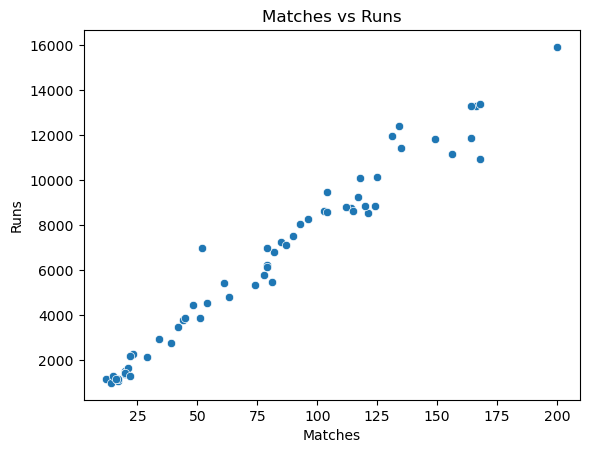

In [ ]:
##########Comparative Analysis#######
#6.Matches vs Runs (relationship)
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="Matches", y="Runs", data=df)
plt.title("Matches vs Runs")
plt.show()

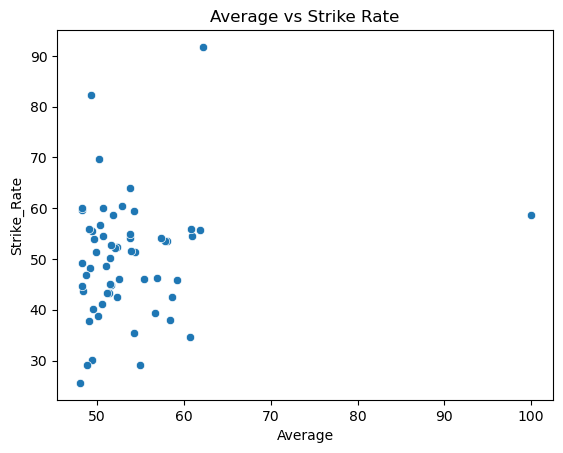

In [ ]:
#7.Average vs Strike Rate
sns.scatterplot(x="Average", y="Strike_Rate", data=df)
plt.title("Average vs Strike Rate")
plt.show()

In [ ]:
#8.Country with most players
df["Country"].value_counts()

Country
AUS        16
ENG        13
WI          8
SA          5
IND         4
PAK         4
SL          3
ICC/SA      2
NZ          2
ICC/IND     2
ICC/WI      1
ZIM         1
ICC/PAK     1
Name: count, dtype: int64

In [ ]:
#9.Country total runs
df.groupby("Country")["Runs"].sum().sort_values(ascending=False)

Country
AUS        105689
ENG         55821
WI          44043
IND         35917
SL          29676
PAK         27641
ICC/SA      22554
ICC/IND     21874
SA          19121
ICC/WI      11953
NZ           9715
ICC/PAK      8830
ZIM          4794
Name: Runs, dtype: int64

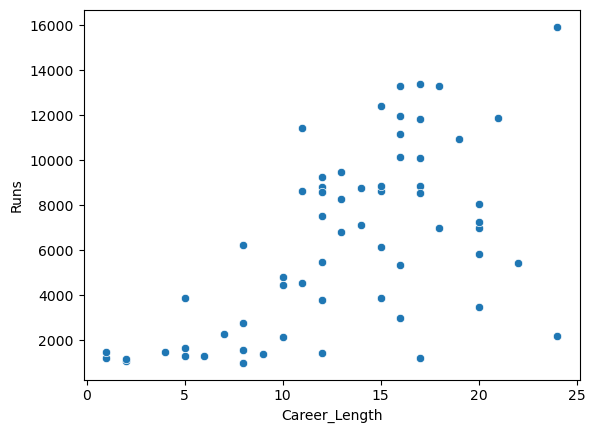

In [ ]:
#10.Career length vs Runs
sns.scatterplot(x="Career_Length", y="Runs", data=df)
plt.show()

In [ ]:
#11.Aggressive players
df.sort_values(by="Strike_Rate", ascending=False).head(10)


,Player,Span,Matches,Innings,Not_Out,Runs,HS,Average,Balls_Faced,Strike_Rate,...,4s,6s,Country,Start_Year,End_Year,Career_Length,Runs_per_Match,Batting_Efficiency,Boundary_Runs,Boundary_Percentage
1,HC Brook,2022-2023,12,20,1,1181,186,62.15,1287.000000,91.76,...,141,23,ENG,2022,2023,1,98.416667,59.050000,702,0.594412
53,V Sehwag,2001-2013,104,180,6,8586,319,49.34,10441.000000,82.23,...,1233,91,ICC/IND,2001,2013,12,82.557692,47.700000,5478,0.638015
45,IVA Richards,1974-1991,121,182,12,8540,291,50.23,15294.233333,69.77,...,952,84,WI,1974,1991,17,70.578512,46.923077,4312,0.504918
25,AD Nourse,1935-1951,34,62,7,2960,231,53.81,15294.233333,63.88,...,115,6,SA,1935,1951,16,87.058824,47.741935,496,0.167568
28,BC Lara,1990-2006,131,232,6,11953,400,52.88,19753.000000,60.51,...,1559,88,ICC/WI,1990,2006,16,91.244275,51.521552,6764,0.565883
41,ML Hayden,1994-2009,103,184,14,8625,380,50.73,14349.000000,60.10,...,1049,82,AUS,1994,2009,15,83.737864,46.875000,4688,0.543536
66,SJ McCabe,1930-1938,39,62,5,2748,232,48.21,15294.233333,60.02,...,241,5,AUS,1930,1938,8,70.461538,44.322581,994,0.361718
63,GC Smith,2002-2014,117,205,13,9265,277,48.25,15525.000000,59.67,...,1165,24,ICC/SA,2002,2014,12,79.188034,45.195122,4804,0.518511
23,VG Kambli,1993-1995,17,21,1,1084,227,54.20,1823.000000,59.46,...,124,6,IND,1993,1995,2,63.764706,51.619048,532,0.490775
33,RT Ponting,1995-2012,168,287,29,13378,257,51.85,22782.000000,58.72,...,1509,73,AUS,1995,2012,17,79.630952,46.613240,6474,0.483929


In [ ]:
#12.Defensive players
df[(df["Average"] > 50) & (df["Strike_Rate"] < 60)]

,Player,Span,Matches,Innings,Not_Out,Runs,HS,Average,Balls_Faced,Strike_Rate,...,4s,6s,Country,Start_Year,End_Year,Career_Length,Runs_per_Match,Batting_Efficiency,Boundary_Runs,Boundary_Percentage
0,DG Bradman,1928-1948,52,80,10,6996,334,99.94,15294.233333,58.60,...,626,6,AUS,1928,1948,20,134.538462,87.450000,2540,0.363065
2,AC Voges,2015-2016,20,31,7,1485,269,61.87,2667.000000,55.68,...,186,5,AUS,2015,2016,1,74.250000,47.903226,774,0.521212
3,RG Pollock,1963-1970,23,41,4,2256,274,60.97,15294.233333,54.48,...,246,11,SA,1963,1970,7,98.086957,55.024390,1050,0.465426
4,GA Headley,1930-1954,22,40,4,2190,270,60.83,15294.233333,56.00,...,104,1,WI,1930,1954,24,99.545455,54.750000,422,0.192694
6,H Sutcliffe,1924-1935,54,84,9,4555,194,60.73,15294.233333,34.59,...,202,6,ENG,1924,1935,11,84.351852,54.226190,844,0.185291
7,E Paynter,1931-1939,20,31,5,1540,243,59.23,15294.233333,45.88,...,125,4,ENG,1931,1939,8,77.000000,49.677419,524,0.340260
8,KF Barrington,1955-1968,82,131,15,6806,256,58.67,15294.233333,42.42,...,591,27,ENG,1955,1968,13,83.000000,51.954198,2526,0.371143
10,WR Hammond,1927-1947,85,140,16,7249,336,58.45,15294.233333,38.07,...,419,27,ENG,1927,1947,20,85.282353,51.778571,1838,0.253552
11,SPD Smith,2010-2023,104,185,22,9472,239,58.11,17690.000000,53.54,...,1038,53,AUS,2010,2023,13,91.076923,51.200000,4470,0.471917
12,GS Sobers,1954-1974,93,160,21,8032,365,57.78,15294.233333,53.58,...,593,32,WI,1954,1974,20,86.365591,50.200000,2564,0.319223


In [ ]:
#Advanced Insights
#IQR → Analysis Section
# Average outliers
Q1 = df["Average"].quantile(0.25)
Q3 = df["Average"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

high_outliers = df[df["Average"] > upper]
low_outliers = df[df["Average"] < lower]

print("High Average Outliers:\n", high_outliers[["Player", "Average"]])
print("Low Average Outliers:\n", low_outliers[["Player", "Average"]])


High Average Outliers:
        Player  Average
0  DG Bradman    99.94
Low Average Outliers:
 Empty DataFrame
Columns: [Player, Average]
Index: []


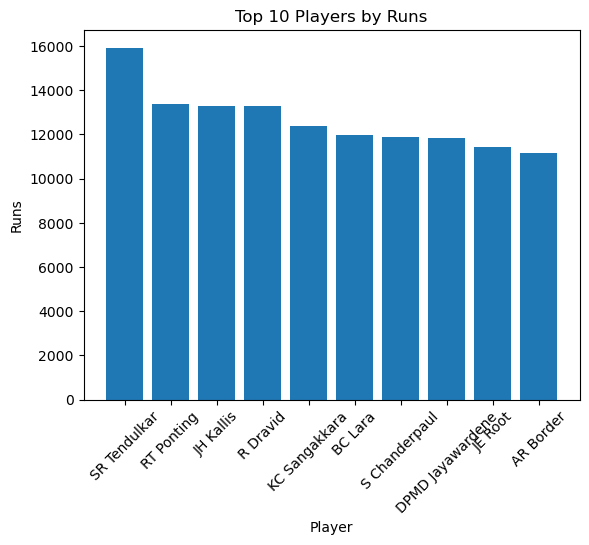

In [ ]:
#step-6 Visualization Tasks 
#1.Bar Chart → Top Players by Runs
top_players = df.sort_values(by="Runs", ascending=False).head(10)

plt.figure()
plt.bar(top_players["Player"], top_players["Runs"])
plt.xticks(rotation=45)
plt.title("Top 10 Players by Runs")
plt.xlabel("Player")
plt.ylabel("Runs")
plt.show()

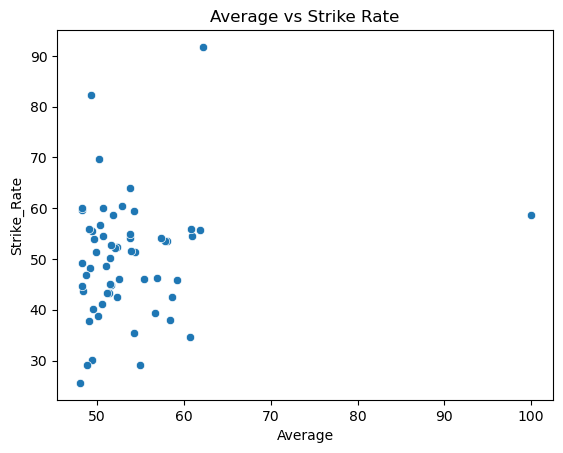

In [ ]:
#2.Scatter Plot → Average vs Strike Rate
plt.figure()
sns.scatterplot(x="Average", y="Strike_Rate", data=df)
plt.title("Average vs Strike Rate")
plt.show()

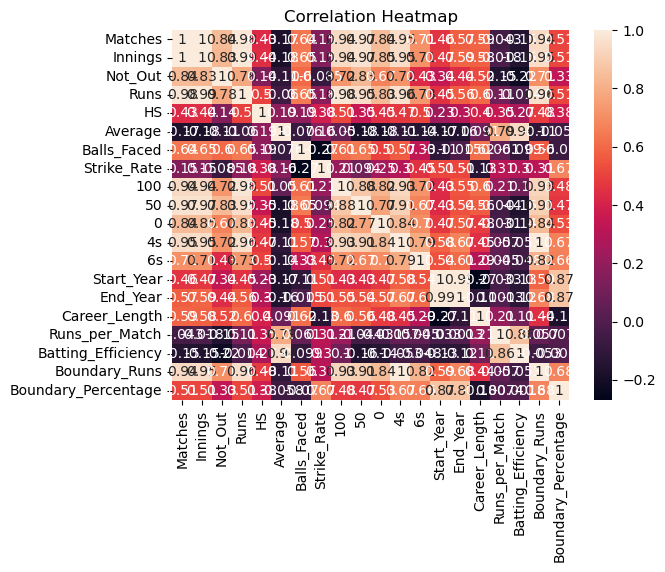

In [ ]:
#3.Heatmap → Correlation Matrix
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

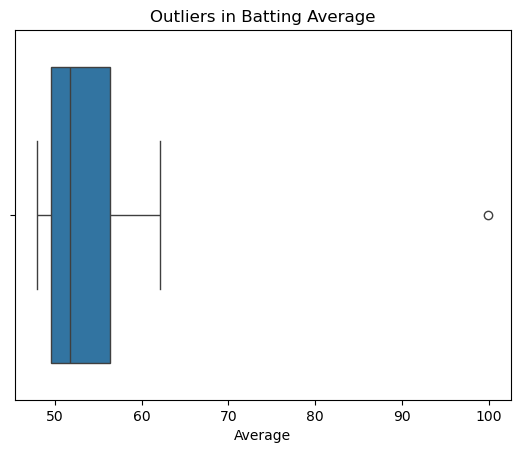

In [ ]:
#4.Boxplot → Detect Outliers
plt.figure()
sns.boxplot(x=df["Average"])
plt.title("Outliers in Batting Average")
plt.show()

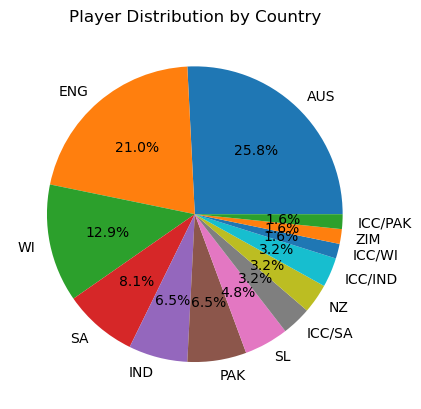

In [ ]:
#5.Pie Chart → Country Distribution
country_counts = df["Country"].value_counts()
plt.figure()
plt.pie(country_counts, labels=country_counts.index, autopct="%1.1f%%")
plt.title("Player Distribution by Country")
plt.show()